In [64]:
import pandas as pd
import matplotlib.pyplot as plt


In [82]:
clust_1_path="/home/jolivera/Documents/CloudSkin/Time-Series-Library/f2f_meeting/comparison_of_approaches/random_forest/job-0/preprocessed/inference_data_eb0e3eaa_b668_4ad6_bc10_2bb0eb7da259_20250923_101701.csv"
clust_2_path="/home/jolivera/Documents/CloudSkin/Time-Series-Library/f2f_meeting/comparison_of_approaches/random_forest/job-0/preprocessed/inference_data_fd7816db_7948_4602_af7a_1d51900792a7_20250923_101701.csv"
df=pd.concat([pd.read_csv(clust_1_path),pd.read_csv(clust_2_path)])
df.sort_values(by='date',inplace=True)

In [83]:
df=df[df["cluster"]=="eb0e3eaa-b668-4ad6-bc10-2bb0eb7da259"]
start_time=1758236454.576562
end_time=1758265256.565292
df.date=pd.to_datetime(df.date)
df=df[df['date']>=pd.to_datetime(start_time,unit="s")]
df=df[df['date']<=pd.to_datetime(end_time,unit="s")]
  

In [84]:
print(pd.to_datetime(start_time,unit="s" ))
print(pd.to_datetime(end_time,unit="s" ))

2025-09-18 23:00:54.576561920
2025-09-19 07:00:56.565291776


In [85]:
df = df.set_index('date')
# Reindex to include all 30-second timestamps, filling missing ones with 0
df = df.asfreq('30S', fill_value=0)
# (Optional) Reset index back to normal columns
df = df.reset_index()


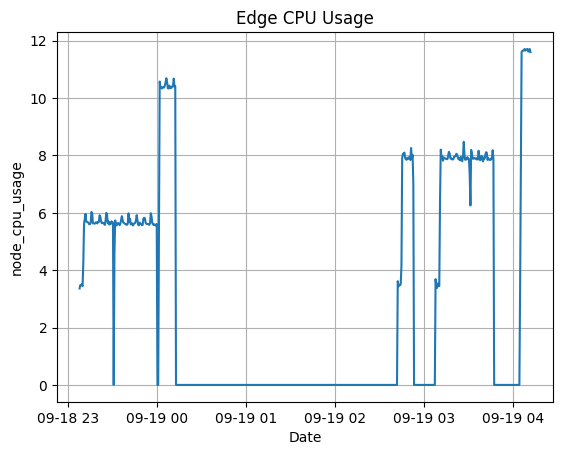

In [87]:
plt.plot(df['date'], df['node_cpu_usage'])
plt.xlabel('Date')
plt.ylabel('node_cpu_usage')
plt.title('Edge CPU Usage')
plt.grid(True)
plt.show()


In [103]:
df["power"]=(df.node_cpu_usage/16)*100
edge_usage=df[df["power"]!=0]
print(edge_usage.power.mean())

44.23701113648343


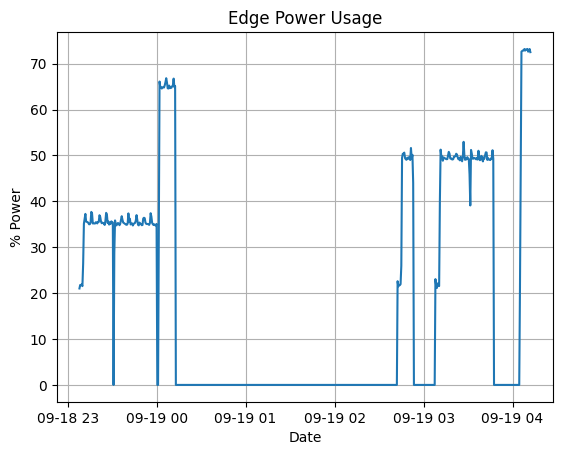

In [104]:
plt.plot(df['date'], df['power'])
plt.xlabel('Date')
plt.ylabel('% Power')
plt.title('Edge Power Usage')
plt.grid(True)
plt.show()


<Axes: >

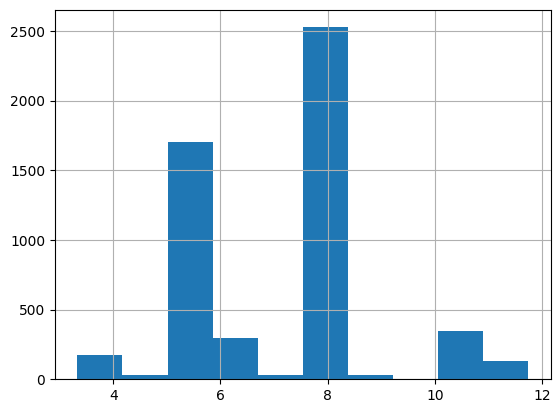

In [63]:
df.node_cpu_usage.hist()

#### Check Control Plane CPU and Memory usage

In [30]:
df=pd.read_csv("/home/jolivera/Documents/CloudSkin/Time-Series-Library/f2f_meeting/comparison_of_approaches/random_forest/job-0/raw/validation-random-forest-job-0_2025-09-18T230054_2025-09-19T070056_created_at_2025-09-19T070058.csv",sep=";")

In [31]:
df

,timestamp,cluster,pipeline_id,governor,pipelines_status_avg_fps,pipelines_status_avg_pipeline_latency,pipelines_status_count_pipeline_latency,pipelines_status_elapsed_time,pipelines_status_frame_count,pipelines_status_realtime_pipeline_latency,pipelines_status_start_time,pipelines_status_sum_pipeline_latency,avg_cluster_cpu_scaling_frequency,node_cpu_usage,node_mem_usage,pipelines_server_cpu_usage,pipelines_server_mem_usage
0,1758236430,eb0e3eaa-b668-4ad6-bc10-2bb0eb7da259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.471333,1.921502e+10,NaN,NaN
1,1758236430,eb0e3eaa-b668-4ad6-bc10-2bb0eb7da259,NaN,performance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.795062e+09,NaN,NaN,NaN,NaN
2,1758236430,f0f802ff-1888-46d5-931b-16897c3f1de7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.663667,8.355521e+09,NaN,NaN
3,1758236430,fd7816db-7948-4602-af7a-1d51900792a7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.750000,7.685001e+09,6.325543,1.761505e+09
4,1758236430,fd7816db-7948-4602-af7a-1d51900792a7,8934d43c94d211f0bd461eaa1ee363d5,NaN,15.001757,0.090712,107654.0,7176.092535,107654.0,0.032046,1.758229e+09,9765.517616,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6786,1758265230,f0f802ff-1888-46d5-931b-16897c3f1de7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.634000,8.454943e+09,NaN,NaN
6787,1758265230,fd7816db-7948-4602-af7a-1d51900792a7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.118000,7.930806e+09,6.890996,1.871307e+09
6788,1758265230,fd7816db-7948-4602-af7a-1d51900792a7,3302f300952211f0aeb0864d942d7843,NaN,15.004371,0.059290,26324.0,1754.422148,26324.0,0.023010,1.758263e+09,1560.746373,NaN,NaN,NaN,NaN,NaN
6789,1758265230,fd7816db-7948-4602-af7a-1d51900792a7,6f7acd00951111f0aeb0864d942d7843,NaN,15.001220,0.078768,134322.0,8954.071471,134322.0,0.033441,1.758256e+09,10580.331638,NaN,NaN,NaN,NaN,NaN


In [34]:
df=df[df["cluster"]=="f0f802ff-1888-46d5-931b-16897c3f1de7"]
df.dropna(axis=1,inplace=True)

<Axes: >

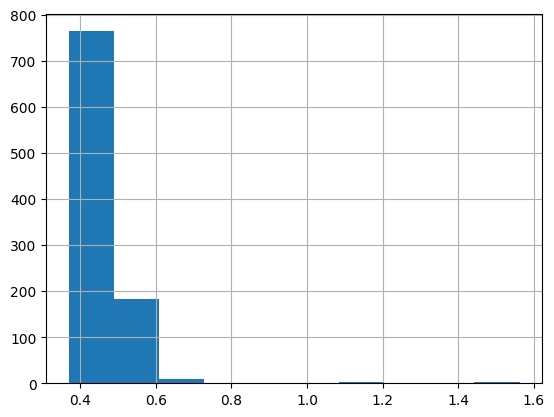

In [36]:
df.node_cpu_usage.hist()

<Axes: >

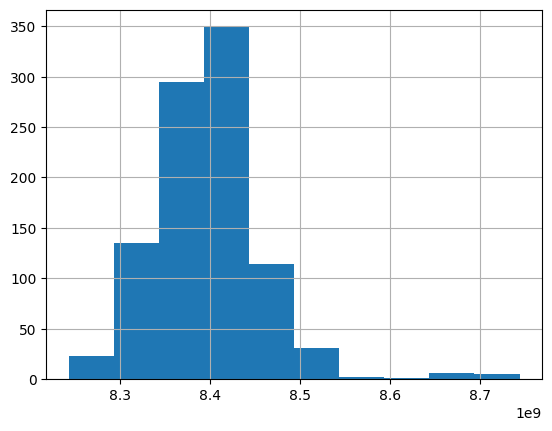

In [37]:
df.node_mem_usage.hist()

In [39]:
df.node_cpu_usage.mean()

0.4724703433922996

<Axes: >

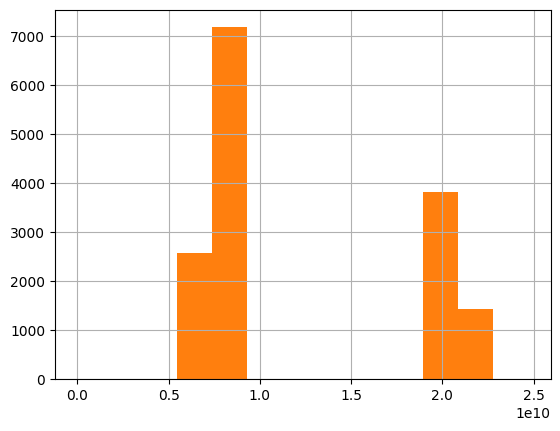

In [13]:
df.node_cpu_usage.hist()
df.node_mem_usage.hist()